In [28]:
import numpy as np
import pandas as pd
import os
import math

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling2D, LSTM, BatchNormalization, GRU, Attention, GlobalAveragePooling1D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dropout

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc

import seaborn as sns



rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정|

### 정형데이터, 정형데이터 + 위성지도 성능 비교 노트북

In [6]:
# 1-1. 사용자 설정 경로 및 변수
GANGNAM_DIRECTORY = '../../data/raw/'
IMAGE_DIRECTORY = '../../data/interim/satellites/gang_nam_rot_90'

TABULAR_DATA_PATH = '../../data/interim/gang_nam_sendimental_score_with_sale.csv'

IMAGE_EXTENSION = '.jpg' # 이미지 파일 확장자 (.png, .jpeg 등)
DATE_COLUMN = '계약일자'
TARGET_COLUMN = '면적당 단가(만원)' # 예측할 실제 타겟 컬럼명

# 1-2. 모델 파라미터
LOOKBACK = 10      # 과거 10개의 거래 데이터를 보고 다음 거래를 예측
BATCH_SIZE = 64
EPOCHS = 100

In [10]:
# 2-1. CSV 파일 로드 및 날짜 기준 정렬
#print("1. 데이터를 로드하고 정렬합니다...")
df = pd.read_csv(TABULAR_DATA_PATH)
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df = df.sort_values(DATE_COLUMN).reset_index(drop=True)
df.drop(columns=['sentiment_score'], axis=1, inplace=True)
df['date'] = df['계약일자'].dt.strftime('%Y-%m')
df.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate,date
0,84.73,5,1994,7.399156,24,2018-07-01,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5,2018-07


In [11]:
# 2-2. 이미지 전체 경로 생성
df['image_filename'] = [f'apt_image_{i}{IMAGE_EXTENSION}' for i in df.index]
df['image_path'] = df['image_filename'].apply(lambda filename: os.path.join(IMAGE_DIRECTORY, filename))

# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename', 'date'])
y_target = df[TARGET_COLUMN]

# 2-4. 숫자형 특징 스케일링
#print("2. 데이터를 전처리합니다...")
numeric_features = X_tabular.select_dtypes(include=np.number).columns.tolist()
#scaler = StandardScaler()
#scaler = RobustScaler()
scaler = MinMaxScaler()
X_tabular[numeric_features] = scaler.fit_transform(X_tabular[numeric_features])
print("=========================")
print("최종 전처리 완료된 데이터 입니다.")
print("=========================\n")
df.info()

최종 전처리 완료된 데이터 입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21561 entries, 0 to 21560
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   전용면적(㎡)         21561 non-null  float64       
 1   층               21561 non-null  int64         
 2   건축년도            21561 non-null  int64         
 3   면적당 단가(만원)      21561 non-null  float64       
 4   아파트 나이          21561 non-null  int64         
 5   계약일자            21561 non-null  datetime64[ns]
 6   leading_index   21561 non-null  float64       
 7   건설기성액(백만원)      21561 non-null  float64       
 8   부동산_소비심리지수      21561 non-null  float64       
 9   주택시장_소비심리지수     21561 non-null  float64       
 10  강남구_변동률         21561 non-null  float64       
 11  강남구_누계          21561 non-null  float64       
 12  토지시장_소비심리지수     21561 non-null  float64       
 13  아파트_호수          21561 non-null  float64       
 14  아파트_면적          21561 non-null  f

## 모델 생성

In [18]:
# 2. 수치형 컬럼만 선택
numeric_features = X_tabular.select_dtypes(include=np.number)

# 3. 수치형 데이터 스케일링
scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(numeric_features)


# 4. MLP 특징 추출기 모델 정의
def create_numeric_feature_extractor(input_shape, embedding_dim=64):
    """
    수치형 데이터를 입력받아 지정된 차원의 특징 벡터(임베딩)를 출력하는 MLP 모델
    """
    input_layer = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    
    # 최종 출력 레이어: 지정된 embedding_dim 차원의 벡터를 출력
    embedding_output = Dense(embedding_dim, activation='relu')(x) 
    
    model = Model(inputs=input_layer, outputs=embedding_output, name='numeric_feature_extractor')
    return model


# 5. 모델 생성 및 특징 추출 실행
# 모델의 입력 차원(input_shape)은 스케일링된 수치형 데이터의 컬럼 수
numeric_extractor_model = create_numeric_feature_extractor(input_shape=X_numeric_scaled.shape[1], embedding_dim=64)
numeric_extractor_model.summary()

# 모델을 사용하여 최종 특징 벡터 추출
print("\n수치형 데이터로부터 특징 벡터 추출을 시작합니다...")
numeric_vectors = numeric_extractor_model.predict(X_numeric_scaled)

print("\n특징 추출이 성공적으로 완료되었습니다!")
print("추출된 숫자형 특징 벡터의 모양:", numeric_vectors.shape)

Model: "numeric_feature_extractor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 14)]              0         
                                                                 
 dense_9 (Dense)             (None, 128)               1920      
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 64)                4160      
                                                                 
Total params: 14,336
Trainable params: 14,336
Non-trainable params: 0
_________________________________________________________________

수치형 데이터로부터 특징 벡터 추출을 시작합니다...
674/674 [==============================] - 0s 146us/step

특징 추출이 성공적으로 완료되었습니다!
추출된 숫자형 특징 벡터의 모양: (21561, 64)


## 시퀀스 데이터 생성

In [19]:
# --- 4. 시퀀스 데이터 생성 ---

print("\n5. 시계열 데이터를 생성합니다...")
def create_sequences(X_data, y_data, lookback):
    X_sequences, y_sequences = [], []
    # 데이터 길이에서 lookback 길이를 뺀 만큼 반복
    for i in range(len(X_data) - lookback):
        # i부터 i+lookback까지의 데이터를 하나의 시퀀스로
        X_sequences.append(X_data[i:(i + lookback)])
        # 시퀀스 바로 다음의 데이터를 정답으로
        y_sequences.append(y_data[i + lookback])
    return np.array(X_sequences), np.array(y_sequences)

# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(numeric_vectors, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]



5. 시계열 데이터를 생성합니다...
생성된 시퀀스 데이터 모양 (X): (21551, 10, 64)
생성된 시퀀스 데이터 모양 (y): (21551,)


## 예측

In [20]:
def create_lstm_model(input_shape):
    input_layer = Input(shape=input_shape)
    x = LSTM(128, activation='relu', return_sequences=True)(input_layer)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)  
    prediction = Dense(1, activation='linear')(x)

    model = Model(inputs=input_layer, outputs=prediction, name='lstm_forecaster')
    return model

In [21]:
def create_future_sequences(all_features, original_df, lookback=10, horizon_days=30):
    """
    특정 기간(horizon_days) 후의 가격을 예측하기 위한 시계열 데이터를 생성합니다.
    
    :param all_features: (샘플 수, 특징 수) 모양의 전체 특징 데이터
    :param original_df: 날짜와 타겟 컬럼이 포함된 원본 데이터프레임
    :param lookback: 과거를 돌아볼 기간 (시퀀스 길이)
    :param horizon_days: 예측할 미래 기간 (일 단위)
    :return: X_sequences (입력 시퀀스), y_sequences (미래 시점의 정답)
    """
    X_sequences, y_sequences = [], []
    
    # 날짜와 타겟 값을 쉽게 조회할 수 있도록 Series로 변환
    dates = original_df['계약일자']
    targets = original_df[TARGET_COLUMN].values
    
    for i in range(len(all_features) - lookback):
        # 입력 시퀀스의 마지막 날짜
        end_of_input_sequence_date = dates[i + lookback - 1]
        
        # 예측 목표 날짜 설정
        target_date = end_of_input_sequence_date + pd.Timedelta(days=horizon_days)
        
        # 목표 날짜 이후의 데이터만 필터링
        future_data_indices = np.where(dates >= target_date)[0]
        
        # 목표 날짜 이후에 거래가 있다면
        if len(future_data_indices) > 0:
            # 가장 가까운 미래 거래의 인덱스를 찾음
            future_target_index = future_data_indices[0]
            
            # 해당 인덱스가 전체 특징 데이터 길이를 벗어나지 않는지 확인
            if future_target_index < len(all_features):
                # 입력 시퀀스 생성
                X_sequences.append(all_features[i:(i + lookback)])
                # 미래 시점의 가격을 정답으로 지정
                y_sequences.append(targets[future_target_index])
                
    return np.array(X_sequences), np.array(y_sequences)

In [23]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(numeric_vectors, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(numeric_vectors, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(numeric_vectors, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 20980
3개월 후 예측용 데이터 샘플 수: 20719
6개월 후 예측용 데이터 샘플 수: 18906


## 각 개월마다 예측

In [25]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]


# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, numeric_vectors.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, numeric_vectors.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, numeric_vectors.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_6m = lstm_model_6m.fit(
    X_train_6m, y_train_6m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_6m, y_test_6m),
    callbacks=[early_stopping],
    verbose=1
)


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100
263/263 [==============================] - 3s 9ms/step - loss: 58.1991 - mae: 7.6184 - val_loss: 63.8182 - val_mae: 7.9786
Epoch 2/100
263/263 [==============================] - 2s 8ms/step - loss: 56.5924 - mae: 7.5117 - val_loss: 60.6230 - val_mae: 7.7741
Epoch 3/100
263/263 [==============================] - 2s 8ms/step - loss: 49.2591 - mae: 6.9364 - val_loss: 42.1347 - val_mae: 6.1032
Epoch 4/100
263/263 [==============================] - 2s 8ms/step - loss: 37.3312 - mae: 5.7584 - val_loss: 39.4894 - val_mae: 5.8572
Epoch 5/100
263/263 [==============================] - 2s 8ms/step - loss: 34.7437 - mae: 5.4886 - val_loss: 36.3563 - val_mae: 5.5591
Epoch 6/100
263/263 [==============================] - 2s 8ms/step - loss: 31.6456 - mae: 5.1463 - val_loss: 32.1242 - val_mae: 5.1077
Epoch 7/100
263/263 [==============================] - 2s 8ms/step - loss: 27.0534 - mae: 4.5712 - val_loss: 25.0101 - val_mae: 4.0948
Epoch 8/100
263/263 [=======


--- 3개월 후 예측 모델 학습 시작 ---
Epoch 1/100
259/259 [==============================] - 3s 8ms/step - loss: 57.9109 - mae: 7.5988 - val_loss: 62.8344 - val_mae: 7.9173
Epoch 2/100
259/259 [==============================] - 2s 9ms/step - loss: 56.6101 - mae: 7.5123 - val_loss: 60.2645 - val_mae: 7.7521
Epoch 3/100
259/259 [==============================] - 2s 8ms/step - loss: 49.1359 - mae: 6.9224 - val_loss: 41.3867 - val_mae: 6.0575
Epoch 4/100
259/259 [==============================] - 2s 8ms/step - loss: 36.5846 - mae: 5.6836 - val_loss: 38.4658 - val_mae: 5.7777
Epoch 5/100
259/259 [==============================] - 2s 8ms/step - loss: 33.7531 - mae: 5.3818 - val_loss: 34.9004 - val_mae: 5.4217
Epoch 6/100
259/259 [==============================] - 2s 8ms/step - loss: 30.4312 - mae: 5.0093 - val_loss: 30.4197 - val_mae: 4.9340
Epoch 7/100
259/259 [==============================] - 2s 8ms/step - loss: 25.9643 - mae: 4.4451 - val_loss: 24.1234 - val_mae: 4.0438
Epoch 8/100
259/259 [=======


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
237/237 [==============================] - 2s 8ms/step - loss: 58.0145 - mae: 7.6056 - val_loss: 63.7083 - val_mae: 7.9734
Epoch 2/100
237/237 [==============================] - 2s 9ms/step - loss: 57.0801 - mae: 7.5438 - val_loss: 62.2622 - val_mae: 7.8819
Epoch 3/100
237/237 [==============================] - 2s 9ms/step - loss: 54.5526 - mae: 7.3716 - val_loss: 56.4073 - val_mae: 7.4901
Epoch 4/100
237/237 [==============================] - 2s 9ms/step - loss: 42.8794 - mae: 6.3335 - val_loss: 41.5736 - val_mae: 6.0735
Epoch 5/100
237/237 [==============================] - 2s 9ms/step - loss: 37.1346 - mae: 5.7390 - val_loss: 39.3886 - val_mae: 5.8556
Epoch 6/100
237/237 [==============================] - 2s 9ms/step - loss: 34.5868 - mae: 5.4707 - val_loss: 36.1654 - val_mae: 5.5366
Epoch 7/100
237/237 [==============================] - 2s 9ms/step - loss: 31.2360 - mae: 5.0922 - val_loss: 30.8527 - val_mae: 4.9689
Epoch 8/100
237/237 [=======

In [26]:

# --- 분석 및 시각화 함수 수정 ---
def analyze_and_visualize_model(model, X_test_seq, y_test_seq, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_seq)

    # ❗️ [수정] y_pred_log의 차원 확인 및 조정
    if y_pred_log.ndim >= 2:
        y_pred_log = y_pred_log.flatten()

    # 2. 역변환 (로그 -> 원본 단위)
    y_pred_original = np.expm1(y_pred_log)

    # ❗️ [수정] y_test_seq도 동일하게 차원 조정 및 역변환
    y_test_original = np.expm1(y_test_seq)
    
    if y_test_original.ndim >= 2:
        y_test_original = y_test_original.flatten()
        
    # ❗️ [수정] 두 배열의 길이를 동일하게 맞춰줍니다.
    #    예측값의 길이를 기준으로 실제값의 길이를 자릅니다.
    min_len = min(len(y_test_original), len(y_pred_original))
    y_test_np = y_test_original[:min_len]
    y_pred_original = y_pred_original[:min_len]


    # 3. 원본 단위(만원)로 MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(min(5, len(y_test_np))):
        print(f"실제 단가: {y_test_np[i]:.2f} (만원)  |  예측 단가: {y_pred_original[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    print(f"Real World MAE: {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    
    min_val = min(y_test_np.min(), y_pred_original.min())
    max_val = max(y_test_np.max(), y_pred_original.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


--- 1개월 후 예측 모델 성능 분석 시작 ---
132/132 [==============================] - 0s 2ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1385.35 (만원)  |  예측 단가: 10630.97 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2004.41 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 3085.04 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2143.09 (만원)
실제 단가: 3639.78 (만원)  |  예측 단가: 2084.86 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1781.94 (만원)


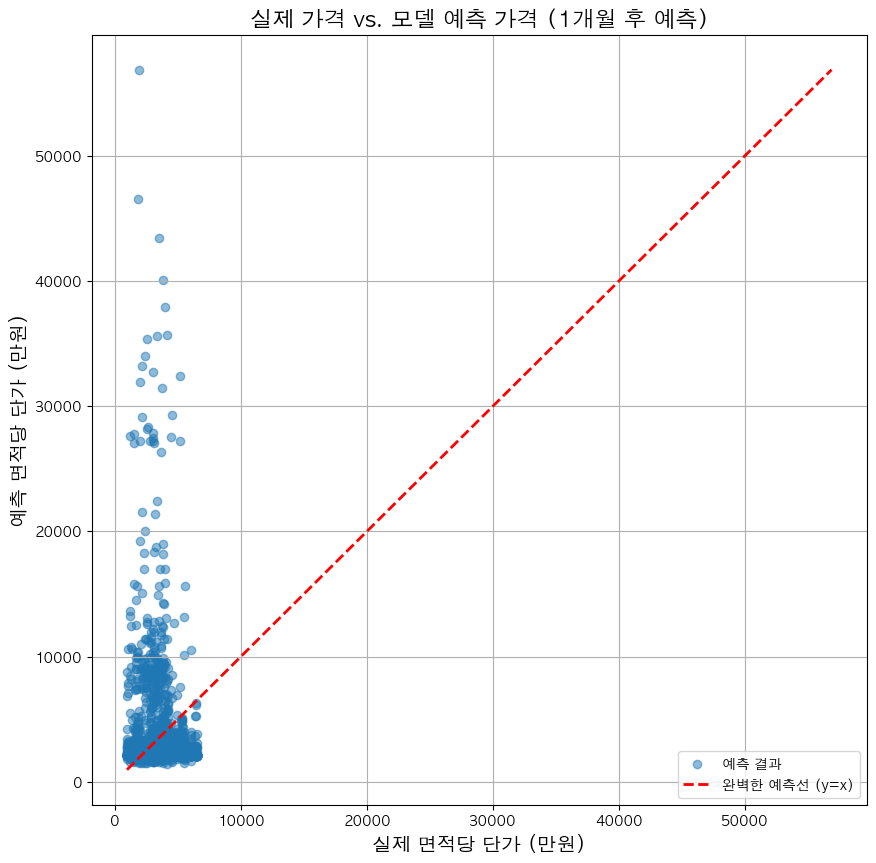


--- 3개월 후 예측 모델 성능 분석 시작 ---
130/130 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1206.20 (만원)  |  예측 단가: 6380.98 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2738.48 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 3122.69 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2134.65 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2037.28 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1784.86 (만원)


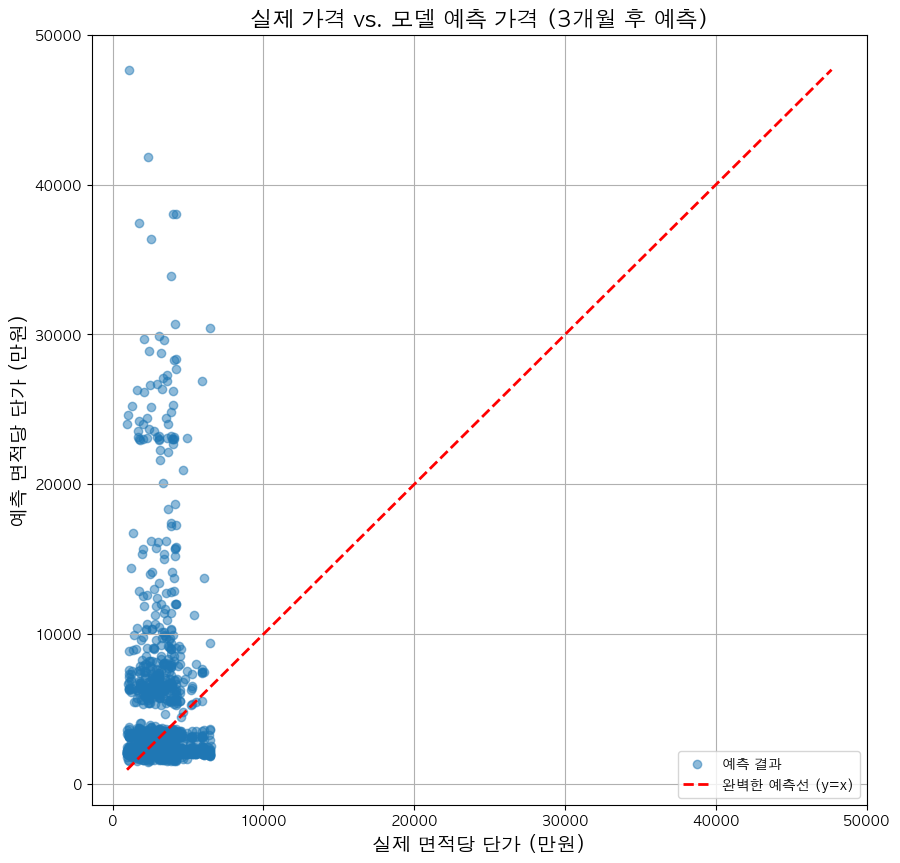


--- 6개월 후 예측 모델 성능 분석 시작 ---
119/119 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 2605.93 (만원)  |  예측 단가: 574.24 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2532.23 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2433.21 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2013.40 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2057.52 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1388.09 (만원)


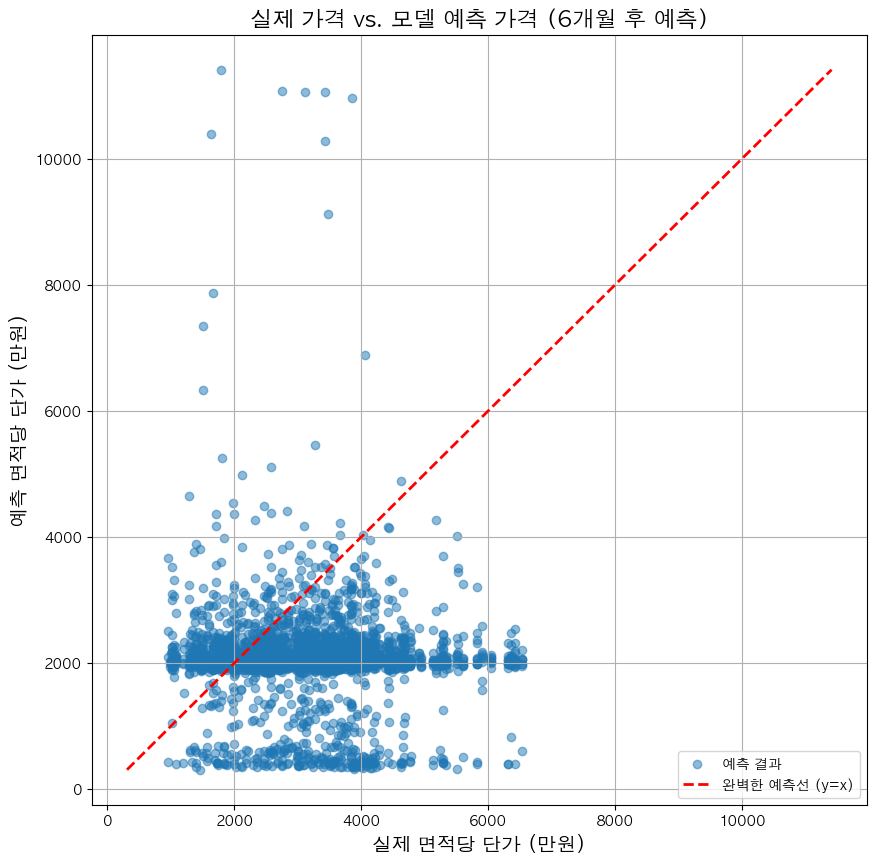

In [29]:

# --- 함수 실행 (기존 코드와 동일) ---
# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석 (만약 모델이 있다면)
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")
